In [1]:
%matplotlib inline

In [4]:
# -*- coding: utf-8 -*-
# ---
# jupyter:
#   jupytext:
#     formats: ipynb,py:light
#     text_representation:
#       extension: .py
#       format_name: light
#       format_version: '1.5'
#       jupytext_version: 1.4.2
#   kernelspec:
#     display_name: Python 3
#     language: python
#     name: python3
# ---

# # Convert dataset
# This notebook converts all EEG files from the Alice dataset to `*.fif` files. It assumes that the dataset is downloaded at the location `SRC` specified in the first cell. The converted data will be saved at the location specified in the `DST` variable. 

# +
# %matplotlib inline
# Basic imports
from pathlib import Path
import shutil
import warnings

import eelbrain
import mne
#from mne.externals.pymatreader import read_mat
from pymatreader import read_mat
import numpy
from scipy.linalg import pinv

/var/folders/dt/yj00f34n5x52_p314tnwfjkw0000gn/T/ipykernel_50406/2793320893.py:39: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  montage.plot()


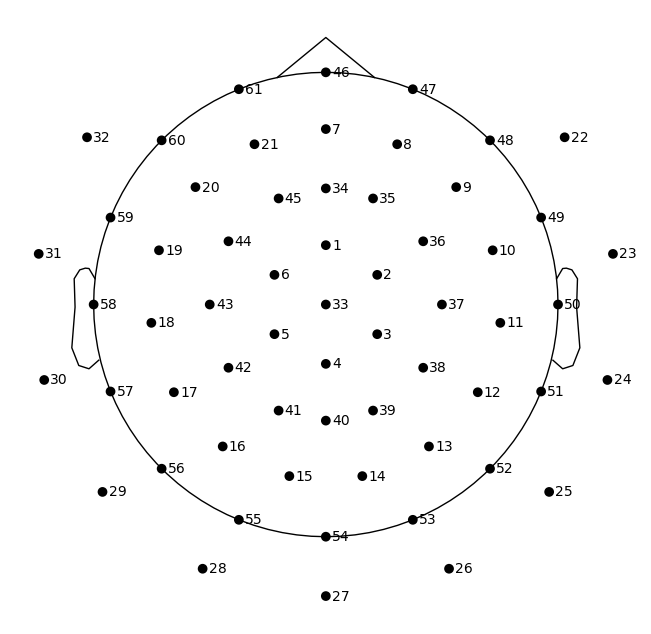

['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61']


"\n# ## Find subject data\n\n# +\n# find subjects\ndatasets = read_mat(SRC / 'datasets.mat')\nsubjects = [s[:3] for s in datasets['use']]\n\n# find audio start locations\nword_table = eelbrain.load.tsv(SRC / 'AliceChapterOne-EEG.csv')\nsegment_start = {}  # segment start relative to first word\nfor segment in range(1, 13):\n    first_word = word_table['Segment'].index(segment)[0]\n    segment_start[segment] = -word_table[first_word, 'onset']\n# -\n\n# ## Convert EEG recordings\n# For subjects S26, S34, S35 and S36, the first event is missing, and labels are shifted by 1.\n\n# +\nwarnings.filterwarnings('ignore', category=RuntimeWarning)\nfor subject in subjects:\n    dst_dir = DST / 'eeg' / subject\n    dst_dir.mkdir(exist_ok=True, parents=True)\n    dst = dst_dir / f'{subject}_alice-raw.fif'\n    if dst.exists():\n        continue\n\n    proc = read_mat(SRC / 'proc' / f'{subject}.mat')['proc']\n    assert proc['subject'] == subject\n    raw = mne.io.read_raw_fieldtrip(SRC / f'{subject

In [7]:
"""
# Location of the Alice dataset
SRC = Path('/Volumes/GoogleDrive/Shared drives/WS2020/alice-dataset')
DST = Path('~').expanduser() / 'Data' / 'Alice'
# -

# ## Copy stimuli

DST_STIMULI = DST / 'stimuli'
DST_STIMULI.mkdir(exist_ok=True)
DST_CSV = DST_STIMULI / 'AliceChapterOne-EEG.csv'
if not DST_CSV.exists():
    shutil.copy(SRC / 'AliceChapterOne-EEG.csv', DST_STIMULI)
for segment in range(1, 13):
    src_file = SRC / 'audio' / f'DownTheRabbitHoleFinal_SoundFile{segment}.wav'
    dst_file = DST_STIMULI / f'{segment}.wav'
    if not dst_file.exists():
        shutil.copy(src_file, dst_file)
"""
# ## Import sensor map

# +
ch_default = {
  'scanno': 307,
  'logno': 1,
  'kind': 3,
  'range': 1.0,
  'cal': 1.0,
  'coil_type': 0,
  'loc': numpy.array([0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1.]),
  'unit': 107,
  'unit_mul': 0,
  'coord_frame': 0,
}

#Data_root = "/Users/neuroling/Downloads/DINGHSIN_Results/Alice_Experiments_Results/TRFs_pridictors"
samplingrate = 500
montage = mne.channels.read_custom_montage('/Users/neuroling/Downloads/DINGHSIN_Results/Alice_Experiments_Results/TRFs_pridictors/easycapM10-acti61_elec.sfp')
montage.plot()

# Print the original 61 channel names from the .sfp file
original_channels = montage.ch_names
print(original_channels)
"""
info = mne.create_info(montage.ch_names, samplingrate, 'eeg')
info.set_montage(montage)
info['highpass'] = 0.1
info['lowpass'] = 200
for ch_name in ['VEOG', 'Aux5', 'AUD']:
    info['chs'].append({**ch_default, 'ch_name': ch_name})
    info['ch_names'].append(ch_name)
    info['nchan'] += 1
# -
"""

"""
# ## Find subject data

# +
# find subjects
datasets = read_mat(SRC / 'datasets.mat')
subjects = [s[:3] for s in datasets['use']]

# find audio start locations
word_table = eelbrain.load.tsv(SRC / 'AliceChapterOne-EEG.csv')
segment_start = {}  # segment start relative to first word
for segment in range(1, 13):
    first_word = word_table['Segment'].index(segment)[0]
    segment_start[segment] = -word_table[first_word, 'onset']
# -

# ## Convert EEG recordings
# For subjects S26, S34, S35 and S36, the first event is missing, and labels are shifted by 1.

# +
warnings.filterwarnings('ignore', category=RuntimeWarning)
for subject in subjects:
    dst_dir = DST / 'eeg' / subject
    dst_dir.mkdir(exist_ok=True, parents=True)
    dst = dst_dir / f'{subject}_alice-raw.fif'
    if dst.exists():
        continue

    proc = read_mat(SRC / 'proc' / f'{subject}.mat')['proc']
    assert proc['subject'] == subject
    raw = mne.io.read_raw_fieldtrip(SRC / f'{subject}.mat', info, 'raw')
    raw._data *= 1e-6  # FieldTrip data in µV

    # reference
    assert proc['implicitref'] == '29'
    assert proc['refchannels'] == ['25', '29']
    mne.add_reference_channels(raw, '29', False)
    raw.set_montage(montage)
    # raw.plot_sensors(show_names=True)
    raw.set_eeg_reference(['25', '29'])
    
    # events
    assert proc['varnames'] == ['segment', 'tmin', 'Order']
    data = proc['trl']
    proc_table = eelbrain.Dataset({
        'istart': data[:, 0],
        'istop': data[:, 1],
        'bl': data[:, 2],
        'segment': data[:, 4 if subject == 'S02' else 3],
        'tstart': data[:, 5 if subject == 'S02' else 4],
    })
    # fix events for subjects missing trial 1
    if subject in ('S26', 'S34', 'S35', 'S36'):
        proc_table['segment'] += 1
    # collect stimulus onset times
    onsets = []
    segments = []
    for segment in range(1, 13):
        if segment not in proc_table['segment']:
            continue
        segments.append(segment)
        first_word = proc_table['segment'].index(segment)[0]
        tstart = proc_table[first_word, 'istart'] / samplingrate - proc_table[first_word, 'tstart'] - proc_table[first_word, 'bl'] / samplingrate
        onsets.append(tstart)
    events = mne.Annotations(onsets, [0.1] * len(onsets), segments)
    raw.set_annotations(events)
    
    # ICA
    mixing = pinv(proc['ica']['unmixing'])
    index = [raw.ch_names.index(ch) for ch in proc['ica']['topolabel']]
    sources = proc['ica']['unmixing'].dot(raw._data[index])
    reject = [int(i) - 1 for i in proc['ica']['rejcomp']]
    sources[reject] = 0
    raw._data[index] = mixing.dot(sources)
    
    # Bad channels
    raw.info['bads'] = proc['rejections']['badchans']
    # Add a bad channel that was missed
    if subject == 'S44':
        raw.info['bads'].append('27')
    elif subject in ('S11', 'S25'):
        raw.info['bads'].append('29')

    # Save 
    raw.save(dst)
"""